**Optimización de hiperparámetros**

En este notebook se aborda la optimización de hiperparámetros. Utilizaremos los datos ya preprocesados y buscaremos las mejores configuraciones para nuestros modelos utilizando validación cruzada mediante dos enfoques: GridSearchCV y RandomizedSearchCV.

### Requisitos de software: este notebook fue desarrollado usando Python 3.14 y las siguientes librerías necesarias:

* pandas 3.0.2
* matplotlib 3.10.9
* scikit-learn (sklearn) 1.8.0
* joblib 1.5.3
* scipy 1.17.1

In [1]:
import pandas as pd
import numpy as np
import joblib
import scipy

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint, loguniform

from pathlib import Path
import sys

# Configura la ruta para importar módulos personalizados
project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    project_root = project_root.parent
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

# Importa funciones creadas
from hyperparameter_tuning import optimizar_grid_search, optimizar_random_search
from model_evaluation import evaluar_regresor
from hyperparameter_tuning import reporte_evaluacion
from hyperparameter_tuning import reporte_evaluacion_reg

from model_evaluation import comparar_modelos_regresion
from model_evaluation import comparar_modelos_clasificacion
from model_evaluation import graficar_comparacion_metricas

# Define rutas relativas al proyecto
base_dir = project_root if "project_root" in globals() else Path.cwd().resolve()
ruta_modelos = base_dir / "models"
ruta_datos = base_dir / "data" / "processed"

# 1. Optimización para DecisionTreeRegressor

## Carga de datos y pipelines

In [3]:
# Carga los conjuntos de prueba
X_test = joblib.load(ruta_datos / "X_test_reg.joblib")
y_test = joblib.load(ruta_datos / "y_test_reg.joblib")

# Carga los conjuntos de entrenamiento
X_train = joblib.load(ruta_datos / "X_train_reg.joblib")
y_train = joblib.load(ruta_datos / "y_train_reg.joblib")

# Carga el modelo entrenado
pipeline_modelo_dtr = joblib.load(ruta_modelos / "pipeline_modelo_dtr_reg.joblib")

print(f"Datos cargados. X_test shape: {X_test.shape}. Modelo listo para evaluar.")

Datos cargados. X_test shape: (3800, 10). Modelo listo para evaluar.


## Enfoque 1: Búsqueda con GridSearchCV

In [4]:
# Define el espacio de búsqueda
param_grid_dtr = {
    'modelo__max_depth': [3, 5, 7, 10, None],
    'modelo__min_samples_split': [2, 10, 20],
    'modelo__min_samples_leaf': [1, 5, 15, 30]
}

# Ejecuta GridSearchCV
mejor_modelo_dtr, mejores_params_dtr = optimizar_grid_search(
    pipeline = pipeline_modelo_dtr,
    param_grid = param_grid_dtr,
    X_train = X_train,
    y_train = y_train,
    cv = 5,
    scoring = 'r2'
)

Iniciando GridSearchCV...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

--- Resultados GridSearchCV ---
Mejores parámetros: {'modelo__max_depth': 3, 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 2}
Mejor score (r2): -0.0018


## Enfoque 2: Búsqueda con RandomizedSearchCV

In [5]:
# Define un espacio de búsqueda amplio con scipy.stats.randint
param_dist_dtr = {
    # randint(a, b) explora enteros aleatorios entre "a" y "b-1"
    'modelo__max_depth': randint(3, 25), 
    'modelo__min_samples_split': randint(2, 50),
    'modelo__min_samples_leaf': randint(1, 40)
}

mejor_modelo_random, mejores_params_random = optimizar_random_search(
    pipeline = pipeline_modelo_dtr,
    param_distributions = param_dist_dtr,
    X_train = X_train,
    y_train = y_train,
    n_iter = 60,
    cv = 5,
    scoring = 'r2',
    random_state = 42
)

Iniciando RandomizedSearchCV con 60 iteraciones...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

--- Resultados RandomizedSearchCV ---
Mejores parámetros: {'modelo__max_depth': 3, 'modelo__min_samples_leaf': 8, 'modelo__min_samples_split': 25}
Mejor score (r2): -0.0018


## Evaluación y Comparación

In [6]:
print("--- Evaluación: Modelo de GridSearchCV ---")
metricas_grid = evaluar_regresor(mejor_modelo_dtr, X_test, y_test)
print(f"Mejores parámetros: {mejores_params_dtr}")
print(f"R2: {metricas_grid['R2']:.3f} | MAE: {metricas_grid['MAE']:,.0f}\n")

print("--- Evaluación: Modelo de RandomizedSearchCV ---")
metricas_random = evaluar_regresor(mejor_modelo_random, X_test, y_test)
print(f"Mejores parámetros: {mejores_params_random}")
print(f"R2: {metricas_random['R2']:.3f} | MAE: {metricas_random['MAE']:,.0f}")

--- Evaluación: Modelo de GridSearchCV ---
Mejores parámetros: {'modelo__max_depth': 3, 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 2}
R2: -0.000 | MAE: 119,281

--- Evaluación: Modelo de RandomizedSearchCV ---
Mejores parámetros: {'modelo__max_depth': 3, 'modelo__min_samples_leaf': 8, 'modelo__min_samples_split': 25}
R2: -0.000 | MAE: 119,281


In [7]:
# Prepara el diccionario para la evaluación
modelos_entrenados = {
    "Modelo de GridSearchCV": mejor_modelo_dtr,
    "Modelo de RandomizedSearchCV": mejor_modelo_random
}

# Evaluamos y ordenamos priorizando un menor RMSE
df_comparacion = comparar_modelos_regresion(modelos_entrenados, X_test, y_test, sort_by="RMSE")
display(df_comparacion)

,MAE,RMSE,R2
Modelo,,,
Modelo de GridSearchCV,119280.614037,149572.928839,-0.000167
Modelo de RandomizedSearchCV,119280.614037,149572.928839,-0.000167


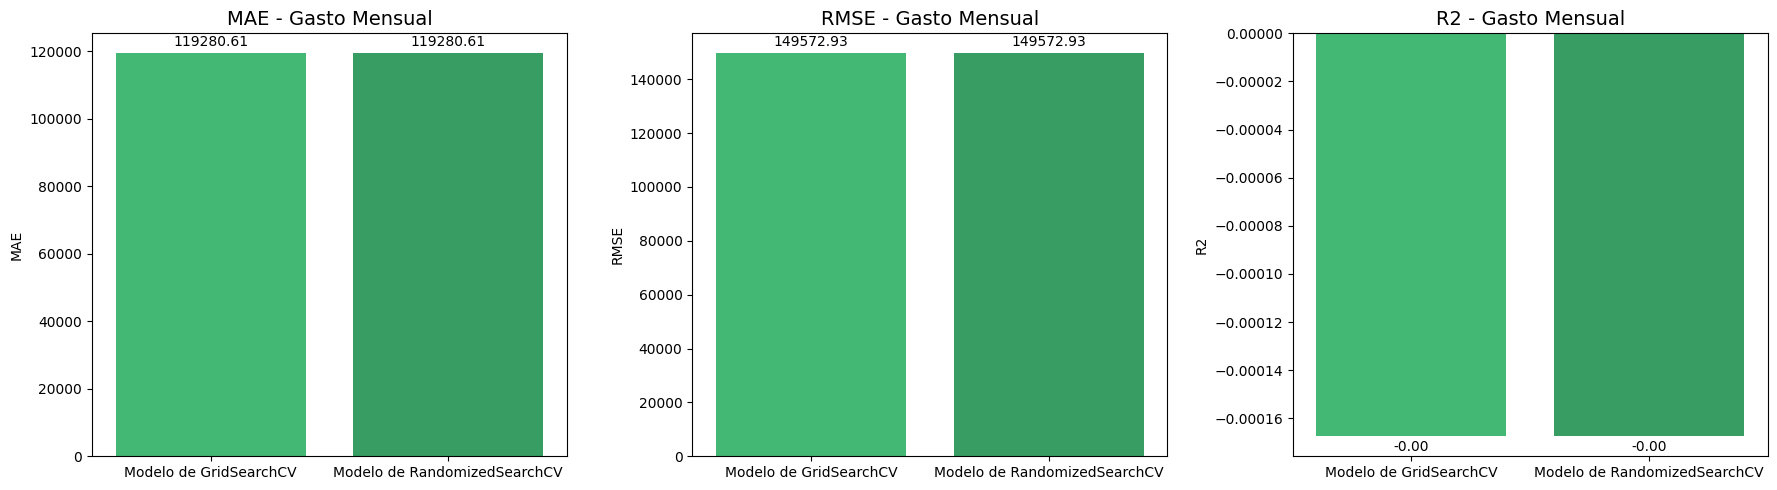

In [8]:
graficar_comparacion_metricas(
    df_metricas = df_comparacion, 
    metricas = ["MAE", "RMSE", "R2"], 
    target_name = "Gasto Mensual", 
    colores = ["#2ECC71", "#27AE60"], 
    label_fmt = "%.2f"
)

In [ ]:
# Evalúa los modelos
reporte_evaluacion_reg("Modelo de GridSearchCV", mejor_modelo_dtr, X_test, y_test)
reporte_evaluacion_reg("Modelo de RandomizedSearchCV", mejor_modelo_random, X_test, y_test)


Evaluación Final: Modelo de GridSearchCV
MAE                 : 119280.6140
RMSE                : 149572.9288
R2 Score            : -0.0002

Evaluación Final: Modelo de RandomizedSearchCV
MAE                 : 119280.6140
RMSE                : 149572.9288
R2 Score            : -0.0002


### Interpretación de Resultados

1. Análisis del rendimiento ($R^2$ y MAE)
Ambos enfoques de optimización arrojaron resultados idénticos en su evaluación final:
- $R^2$ de 0.000: Un $R^2$ de cero (o ligeramente negativo) significa que el modelo no logra capturar la varianza de la variable objetivo. El modelo no tiene capacidad predictiva y su comportamiento es equivalente a un modelo que simplemente predice siempre el promedio del target, sin importar las características de entrada.
- MAE de 119,281: Nuestras predicciones tienen un error promedio de 119,281 unidades respecto al valor real. Al tener un $R^2$ de 0, este MAE representa básicamente el error de predecir la media en todos los casos. 

2. Comportamiento de los hiperparámetros

    Mejores configuraciones:
- GridSearchCV: max_depth=3, min_samples_leaf=1, min_samples_split=2
- RandomizedSearchCV: max_depth=3, min_samples_leaf=8, min_samples_split=25

- Ambos métodos determinaron que el "mejor" modelo es un árbol poco profundo (max_depth = 3). Aunque el Random Search escogió reglas más estrictas para las hojas y divisiones, el resultado fue el mismo. Esto indica que, a partir del tercer nivel de profundidad, el árbol no encuentra divisiones que reduzcan el error de manera significativa.

3. Conclusiones: El resultado evidencia un caso de underfitting, donde el algoritmo no encuentra patrones útiles. Esto no es un problema sobre la optimización de hiperparámetros, sino la naturaleza de los datos. 

In [8]:
base_dir = project_root if "project_root" in globals() else Path.cwd().resolve()

models_dir = base_dir / "models"
models_dir.mkdir(parents=True, exist_ok=True)

# Guarda los modelos de regresión optimizados
joblib.dump(mejor_modelo_dtr, models_dir / "mejor_modelo_dtr.joblib")
joblib.dump(mejor_modelo_random, models_dir / "mejor_modelo_random_dtr.joblib") # Árbol de decisión optimizado con RandomizedSearchCV

print("Modelos de regresión optimizados guardados")

Modelos de regresión optimizados guardados


# 2. Optimización de hiperparámetros para modelos de clasificación

## Carga de datos y pipeline

In [9]:
# Carga los conjuntos de prueba específicos para clasificación
X_test_clf = joblib.load(ruta_datos / "X_test_clf.joblib")
y_test_clf = joblib.load(ruta_datos / "y_test_clf.joblib")

# Carga los conjuntos de entrenamiento específicos para clasificación
X_train_clf = joblib.load(ruta_datos / "X_train_clf.joblib")
y_train_clf = joblib.load(ruta_datos / "y_train_clf.joblib")

# Carga los modelos de clasificación entrenados
pipeline_modelo_lr_clf = joblib.load(ruta_modelos / "pipeline_modelo_lr_clf.joblib")
pipeline_modelo_dtc_clf = joblib.load(ruta_modelos / "pipeline_modelo_dtc_clf.joblib")
pipeline_modelo_svm_clf = joblib.load(ruta_modelos / "pipeline_modelo_svm_clf.joblib")

## Enfoque 1: Búsqueda con GridSearchCV

In [10]:
# GridSearchCV: Regresión Logística
param_grid_lr = {
    'modelo__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'modelo__penalty': ['l1', 'l2'],
    'modelo__solver': ['liblinear', 'saga']
}
print(">> Optimizando Regresión Logística (GridSearch)")
mejor_lr_grid, params_lr_grid = optimizar_grid_search(
    pipeline = pipeline_modelo_lr_clf, 
    param_grid = param_grid_lr, 
    X_train = X_train_clf, 
    y_train = y_train_clf, 
    cv = 5, 
    scoring = 'roc_auc'
)

# GridSearchCV: Decision Tree Classifier
param_grid_dtc = {
    'modelo__max_depth': [3, 5, 7, 10, None],       
    'modelo__min_samples_split': [2, 5, 10],        
    'modelo__min_samples_leaf': [1, 2, 5, 10],      
    'modelo__criterion': ['gini', 'entropy']        
}
print("\n>> Optimizando Decision Tree (GridSearch)")
mejor_dtc_grid, params_dtc_grid = optimizar_grid_search(
    pipeline = pipeline_modelo_dtc_clf, 
    param_grid = param_grid_dtc, 
    X_train = X_train_clf, 
    y_train = y_train_clf, 
    cv = 5, 
    scoring = 'roc_auc'
)

# GridSearchCV: Support Vector Machine
param_grid_svm = {
    'modelo__C': [0.1, 1, 10],
    'modelo__gamma': ['scale', 'auto']
}
print("\n>> Optimizando SVM (GridSearch)")
mejor_svm_grid, params_svm_grid = optimizar_grid_search(
    pipeline = pipeline_modelo_svm_clf, 
    param_grid = param_grid_svm, 
    X_train = X_train_clf, 
    y_train = y_train_clf, 
    cv = 3, # Validación cruzada reducida por el costo computacional de SVM
    scoring = 'roc_auc'
)

>> Optimizando Regresión Logística (GridSearch)
Iniciando GridSearchCV...
Fitting 5 folds for each of 24 candidates, totalling 120 fits


c:\Users\david\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



--- Resultados GridSearchCV ---
Mejores parámetros: {'modelo__C': 0.01, 'modelo__penalty': 'l2', 'modelo__solver': 'saga'}
Mejor score (roc_auc): 0.6656

>> Optimizando Decision Tree (GridSearch)
Iniciando GridSearchCV...
Fitting 5 folds for each of 120 candidates, totalling 600 fits

--- Resultados GridSearchCV ---
Mejores parámetros: {'modelo__criterion': 'entropy', 'modelo__max_depth': 5, 'modelo__min_samples_leaf': 10, 'modelo__min_samples_split': 2}
Mejor score (roc_auc): 0.6614

>> Optimizando SVM (GridSearch)
Iniciando GridSearchCV...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

--- Resultados GridSearchCV ---
Mejores parámetros: {'modelo__C': 0.1, 'modelo__gamma': 'auto'}
Mejor score (roc_auc): 0.6699


In [11]:
# Prepara el diccionario para la evaluación
modelos_GridSearchCV = {
    "Regresión Logística": mejor_lr_grid,
    "Decision Tree Classifier": mejor_dtc_grid,
    "Support Vector Machine": mejor_svm_grid
}

# Evaluamos y ordenamos priorizando un menor RMSE
df_comparacion = comparar_modelos_clasificacion(modelos_GridSearchCV, X_test_clf, y_test_clf, sort_by="RMSE")
display(df_comparacion)

,accuracy,f1,roc_auc
Modelo,,,
Regresión Logística,0.62450,0.568143,0.675107
Decision Tree Classifier,0.62275,0.574330,0.670032
Support Vector Machine,0.62300,0.576166,0.677199


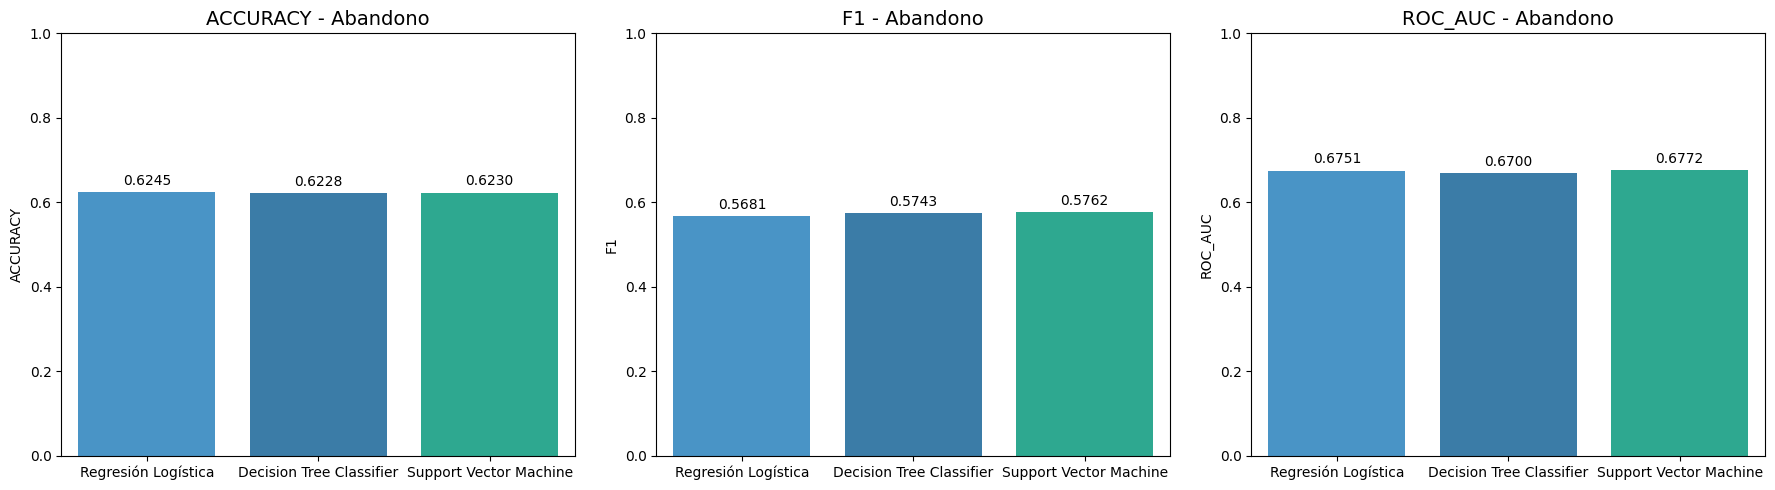

In [12]:
graficar_comparacion_metricas(
    df_metricas = df_comparacion,
    metricas = ["accuracy", "f1", "roc_auc"],
    target_name = "Abandono",
    colores = ["#3498DB", "#2980B9", "#1ABC9C"],
    y_lim = (0, 1.0),
    label_fmt = "%.4f"
)

## Enfoque 2: Búsqueda con RandomizedSearchCV

In [13]:
# RandomizedSearchCV: Regresión Logística
param_dist_lr = {
    'modelo__C': loguniform(1e-3, 1e2),
    'modelo__penalty': ['l1', 'l2'],
    'modelo__solver': ['liblinear', 'saga']
}
print(">> Optimizando Regresión Logística (RandomSearch)")
mejor_lr_random, params_lr_random = optimizar_random_search(
    pipeline = pipeline_modelo_lr_clf, 
    param_distributions = param_dist_lr, 
    X_train = X_train_clf, 
    y_train = y_train_clf, 
    n_iter = 20, 
    cv = 5, 
    scoring = 'roc_auc'
)

# RandomizedSearchCV: Decision Tree Classifier
param_dist_dtc = {
    'modelo__max_depth': randint(3, 15),       
    'modelo__min_samples_split': randint(2, 15),        
    'modelo__min_samples_leaf': randint(1, 15),      
    'modelo__criterion': ['gini', 'entropy']        
}
print("\n>> Optimizando Decision Tree (RandomSearch)")
mejor_dtc_random, params_dtc_random = optimizar_random_search(
    pipeline = pipeline_modelo_dtc_clf, 
    param_distributions = param_dist_dtc, 
    X_train = X_train_clf, 
    y_train = y_train_clf, 
    n_iter = 30, 
    cv = 5, 
    scoring = 'roc_auc'
)

# RandomizedSearchCV: Support Vector Machine
param_dist_svm = {
    'modelo__C': loguniform(1e-1, 1e1),
    'modelo__gamma': ['scale', 'auto']
}
print("\n>> Optimizando SVM (RandomSearch)")
mejor_svm_random, params_svm_random = optimizar_random_search(
    pipeline = pipeline_modelo_svm_clf, 
    param_distributions = param_dist_svm, 
    X_train = X_train_clf, 
    y_train = y_train_clf, 
    n_iter = 10, 
    cv = 3, 
    scoring = 'roc_auc'
)

>> Optimizando Regresión Logística (RandomSearch)
Iniciando RandomizedSearchCV con 20 iteraciones...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\david\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\david\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(



--- Resultados RandomizedSearchCV ---
Mejores parámetros: {'modelo__C': np.float64(0.19069966103000435), 'modelo__penalty': 'l1', 'modelo__solver': 'saga'}
Mejor score (roc_auc): 0.6656

>> Optimizando Decision Tree (RandomSearch)
Iniciando RandomizedSearchCV con 30 iteraciones...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

--- Resultados RandomizedSearchCV ---
Mejores parámetros: {'modelo__criterion': 'entropy', 'modelo__max_depth': 4, 'modelo__min_samples_leaf': 10, 'modelo__min_samples_split': 10}
Mejor score (roc_auc): 0.6617

>> Optimizando SVM (RandomSearch)
Iniciando RandomizedSearchCV con 10 iteraciones...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

--- Resultados RandomizedSearchCV ---
Mejores parámetros: {'modelo__C': np.float64(0.23273922280628717), 'modelo__gamma': 'auto'}
Mejor score (roc_auc): 0.6710


In [14]:
# Prepara el diccionario para la evaluación
modelos_RandomizedSearchCV = {
    "Regresión Logística": mejor_lr_random,
    "Decision Tree Classifier": mejor_dtc_random,
    "Support Vector Machine": mejor_svm_random
}

# Evaluamos y ordenamos priorizando un menor RMSE
df_comparacion = comparar_modelos_clasificacion(modelos_RandomizedSearchCV, X_test_clf, y_test_clf, sort_by="RMSE")
display(df_comparacion)

,accuracy,f1,roc_auc
Modelo,,,
Regresión Logística,0.62325,0.566331,0.675084
Decision Tree Classifier,0.63700,0.569395,0.671867
Support Vector Machine,0.62475,0.578726,0.676955


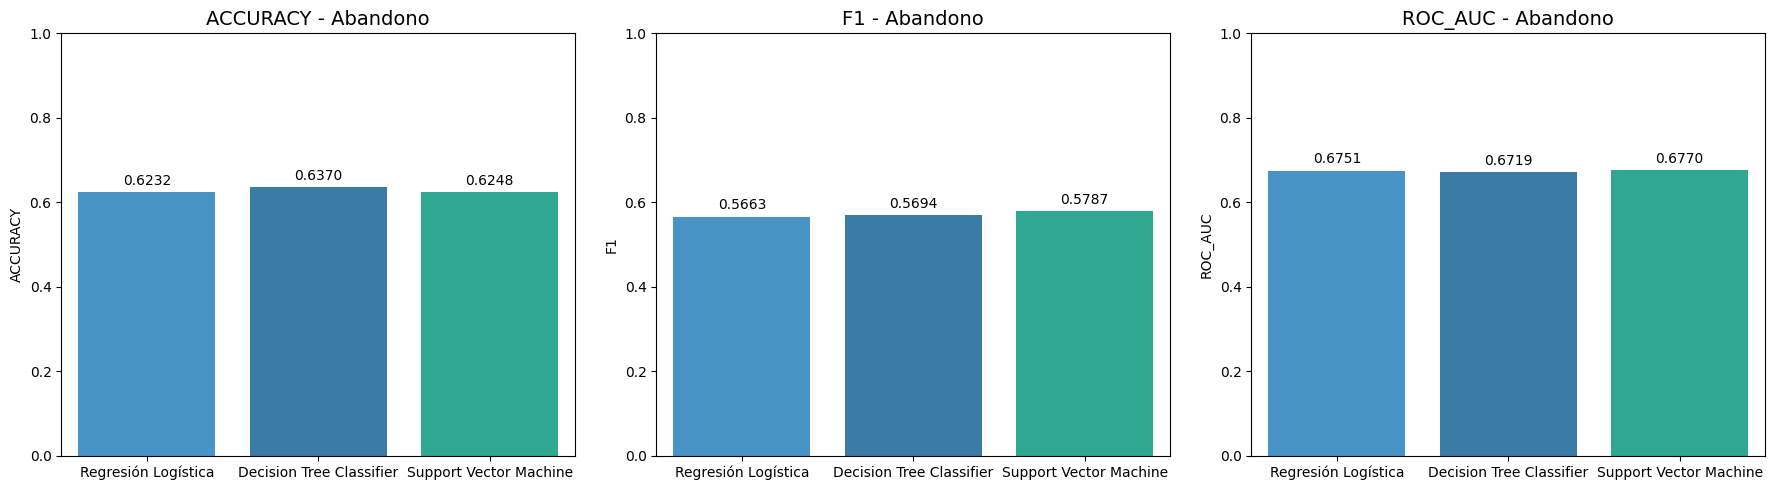

In [15]:
graficar_comparacion_metricas(
    df_metricas = df_comparacion,
    metricas = ["accuracy", "f1", "roc_auc"],
    target_name = "Abandono",
    colores = ["#3498DB", "#2980B9", "#1ABC9C"],
    y_lim = (0, 1.0),
    label_fmt = "%.4f"
)

## Evaluación y comparación

In [16]:
# Evalúa los modelos provenientes de GridSearch
reporte_evaluacion("Regresión Logística (GridSearch)", mejor_lr_grid, X_test_clf, y_test_clf)
reporte_evaluacion("Árbol de Decisión (GridSearch)", mejor_dtc_grid, X_test_clf, y_test_clf)
reporte_evaluacion("SVM (GridSearch)", mejor_svm_grid, X_test_clf, y_test_clf)


Evaluación Final: Regresión Logística (GridSearch)
Accuracy            : 0.6245
F1 Score:           : 0.5681
ROC AUC Score       : 0.6751

Evaluación Final: Árbol de Decisión (GridSearch)
Accuracy            : 0.6228
F1 Score:           : 0.5743
ROC AUC Score       : 0.6700

Evaluación Final: SVM (GridSearch)
Accuracy            : 0.6230
F1 Score:           : 0.5762
ROC AUC Score       : 0.6772


In [17]:
# Evalúa los modelos provenientes de RandomSearch
reporte_evaluacion("Regresión Logística (RandomSearch)", mejor_lr_random, X_test_clf, y_test_clf)
reporte_evaluacion("Árbol de Decisión (RandomSearch)", mejor_dtc_random, X_test_clf, y_test_clf)
reporte_evaluacion("SVM (RandomSearch)", mejor_svm_random, X_test_clf, y_test_clf)


Evaluación Final: Regresión Logística (RandomSearch)
Accuracy            : 0.6232
F1 Score:           : 0.5663
ROC AUC Score       : 0.6751

Evaluación Final: Árbol de Decisión (RandomSearch)
Accuracy            : 0.6370
F1 Score:           : 0.5694
ROC AUC Score       : 0.6719

Evaluación Final: SVM (RandomSearch)
Accuracy            : 0.6248
F1 Score:           : 0.5787
ROC AUC Score       : 0.6770


In [18]:
# Guarda los modelos de clasificación optimizados (RandomizedSearchCV)
joblib.dump(mejor_lr_random, models_dir / "mejor_modelo_lr_random.joblib")
joblib.dump(mejor_dtc_random, models_dir / "mejor_modelo_dtc_random.joblib")
joblib.dump(mejor_svm_random, models_dir / "mejor_modelo_svm_random.joblib")

# Guarda los modelos de clasificación optimizados (GridSearchCV)
joblib.dump(mejor_lr_grid, models_dir / "mejor_modelo_lr_grid.joblib")
joblib.dump(mejor_dtc_grid, models_dir / "mejor_modelo_dtc_grid.joblib")
joblib.dump(mejor_svm_grid, models_dir / "mejor_modelo_svm_grid.joblib")

print("Modelos de clasificación optimizados guardados")

Modelos de clasificación optimizados guardados
